In [11]:
import torch

def pendulum_dynamics(t, state, beta = 0.4, omega_0 = 9.81/2):
    '''
    arguments:
        state = (theta, omega) - current pendulum angle (or angular displacement) and angular velocity of the pendulum
        beta - damping coefficient
        omega_0 - natural frequency of the pendulum (or natural angular frequency)
    
    returns:
        (dtheta_dt, domega_dt)
    '''
    theta = state[..., 0]
    omega = state[..., 1]

    domega_dt = -2*beta*omega - omega_0**2 * torch.sin(theta)
    dtheta_dt = omega

    return torch.stack([dtheta_dt, domega_dt], dim=-1)


Trajektorie treningowe: torch.Size([50, 160, 2])


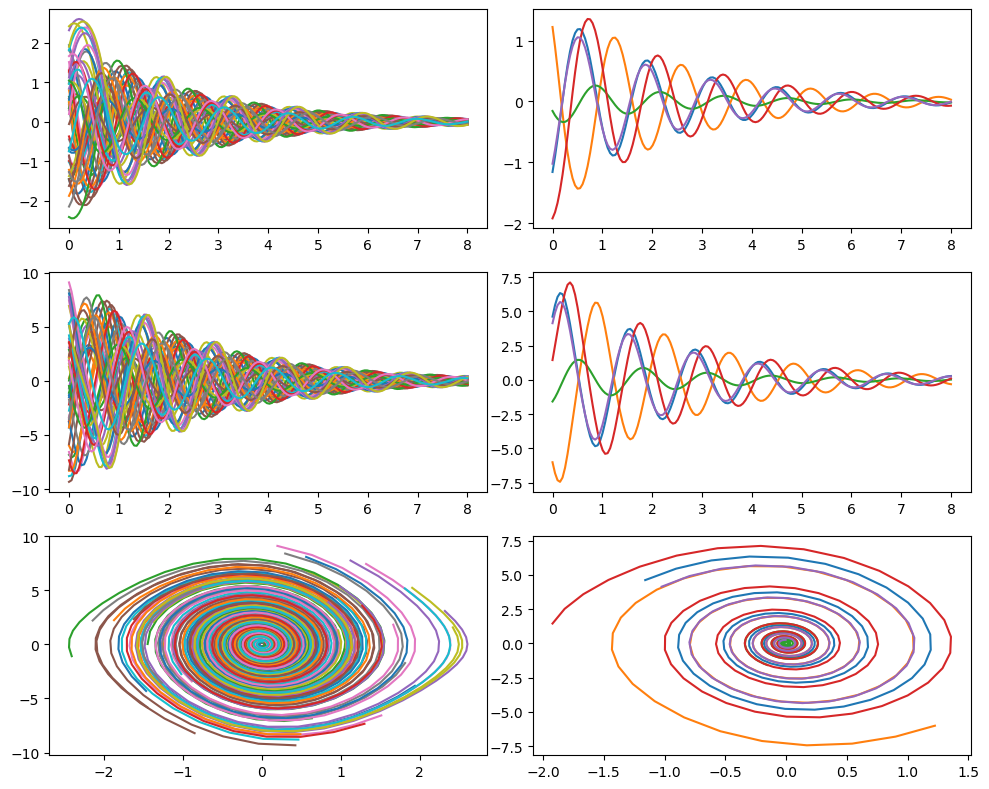

In [12]:
import torch
from torchdiffeq import odeint
from matplotlib import pyplot as plt

NUM_TRAJECTORIES = 50
NUM_TRAJECTORIES_VAL = 5
CHUNK_LEN = 2

T = 8
dt = 0.05
omega_0 = 9.81/2 
ts = torch.linspace(0, T, int(T/dt))
chunk_steps = int(CHUNK_LEN / dt)
num_chunks = int(T / CHUNK_LEN)

torch.manual_seed(42)

def get_safe_batch(num_samples, omega_0):
    """Generuje batch stanów początkowych poniżej bariery energetycznej szczytu."""
    y_0s_list = []
    max_energy = 2 * omega_0**2
    
    while len(y_0s_list) < num_samples:
        # Losujemy z zapasem, by szybko odfiltrować poprawne punkty
        n_to_draw = (num_samples - len(y_0s_list)) * 2
        
        # theta w zakresie (-pi, pi), omega w szerokim zakresie (np. -10, 10)
        theta = (torch.rand(n_to_draw) * 2 * torch.pi) - torch.pi
        omega = (torch.rand(n_to_draw) * 20) - 10
        
        # Obliczamy energię całkowitą (Kinetyczna + Potencjalna)
        energy = 0.5 * omega**2 + omega_0**2 * (1 - torch.cos(theta))
        
        # Warunek: energia mniejsza niż na szczycie (z małym marginesem bezpieczeństwa)
        mask = energy < (max_energy * 0.95)
        
        safe_points = torch.stack([theta[mask], omega[mask]], dim=1)
        y_0s_list.extend(safe_points[:num_samples - len(y_0s_list)])
        
    return torch.stack(y_0s_list)


y_0s = get_safe_batch(NUM_TRAJECTORIES, omega_0)
y_0s_val = get_safe_batch(NUM_TRAJECTORIES_VAL, omega_0)


trajectories_raw = odeint(pendulum_dynamics, y_0s, ts)
trajectories_val_raw = odeint(pendulum_dynamics, y_0s_val, ts)

trajectories = trajectories_raw.permute(1, 0, 2)
trajectories_val = trajectories_val_raw.permute(1, 0, 2)

trajectories_list = [trajectories[i] for i in range(NUM_TRAJECTORIES)]
trajectories_list_val = [trajectories_val[i] for i in range(NUM_TRAJECTORIES_VAL)]

fig, axs = plt.subplots(3, 2, figsize=(10, 8))
for traj in trajectories_list:
    thetas, omegas = traj[:, 0].detach(), traj[:, 1].detach()
    axs[0][0].plot(ts, thetas)
    axs[1][0].plot(ts, omegas)
    axs[2][0].plot(thetas, omegas)

for traj in trajectories_list_val:
    thetas, omegas = traj[:, 0].detach(), traj[:, 1].detach()
    axs[0][1].plot(ts, thetas)
    axs[1][1].plot(ts, omegas)
    axs[2][1].plot(thetas, omegas)

plt.tight_layout()
print(f"Trajektorie treningowe: {trajectories.shape}") # [50, 160, 2]

In [13]:
import torch.nn as nn
from torchdiffeq import odeint_adjoint

class ODEFunc(nn.Module):
    """Neural network that parameterizes dy/dt = f(y, t)."""

    def __init__(self):
        super(ODEFunc, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 2),
        )

    def forward(self, ts, y):
        theta = y[..., 0:1]
        omega = y[..., 1:2]
        features = torch.cat([theta, omega], dim=-1)
        return self.net(features)

In [14]:
class NeuralODE(nn.Module):
    """Wraps ODEFunc and solves it with torchdiffeq (Tsit5 solver)."""

    def __init__(self, odefun):
        super(NeuralODE, self).__init__()
        self.odefun = odefun
    
    def forward(self, y0, ts):
        res = odeint_adjoint(self.odefun, y0, ts)
        return res

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"

ode_func = ODEFunc()
model = NeuralODE(ode_func).to(device)

# Data
y_0s = y_0s.to(device)
y_0s_val = y_0s_val.to(device)
ts = ts.to(device)
trajectories = trajectories.to(device)
trajectories_val = trajectories_val.to(device)

chunked_trajectories = trajectories.view(NUM_TRAJECTORIES, num_chunks, chunk_steps, 2)
chunked_trajectories = chunked_trajectories.reshape(-1, chunk_steps, 2)
chunk_y0s = chunked_trajectories[:, 0, :]
chunk_ts = ts[:chunk_steps]

# Hyperparameters
num_epochs_adam = 1000
num_epochs_bfgs = 100
print_every = 20
criterion = nn.MSELoss()
optimizer1 = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(num_epochs_adam):
    optimizer1.zero_grad()
    predicted_chunks = model(chunk_y0s, chunk_ts).permute(1, 0, 2)
    loss = criterion(predicted_chunks, chunked_trajectories)
    loss.backward()
    optimizer1.step()

    if epoch % print_every == 0:
        with torch.no_grad():
            predicted_traj = model(y_0s_val, ts).permute(1, 0, 2)
            loss_val = criterion(predicted_traj, trajectories_val)
            print(f"Epoch {epoch:4d}, Train Loss: {loss.item():.6f}, Val Loss: {loss_val.item():.6f}")


optimizer2 = torch.optim.LBFGS(
    model.parameters(), 
    lr=0.01,
    max_iter=20,             
    max_eval=25,             
    tolerance_grad=1e-05,    
    tolerance_change=1e-09,  
    history_size=100,        
    line_search_fn='strong_wolfe'
)
for epoch in range(num_epochs_bfgs):
    def closure():
        optimizer2.zero_grad()
        predicted_chunks = model(chunk_y0s, chunk_ts).permute(1, 0, 2)
        loss = criterion(predicted_chunks, chunked_trajectories)
        loss.backward()
        return loss

    optimizer2.step(closure)

    if epoch % print_every == 0:
        with torch.no_grad():
            predicted_traj = model(y_0s_val, ts).permute(1, 0, 2)
            loss_val = criterion(predicted_traj, trajectories_val)
            print(f"Epoch {epoch:4d}, Train Loss: {loss.item():.6f}, Val Loss: {loss_val.item():.6f}")

Epoch    0, Train Loss: 6.001606, Val Loss: 4.664948
Epoch   20, Train Loss: 2.520178, Val Loss: 1.547730
Epoch   40, Train Loss: 2.066079, Val Loss: 1.467954
Epoch   60, Train Loss: 1.862110, Val Loss: 1.438009
Epoch   80, Train Loss: 1.638626, Val Loss: 1.380418
Epoch  100, Train Loss: 1.282363, Val Loss: 1.215419
Epoch  120, Train Loss: 0.592150, Val Loss: 0.556614
Epoch  140, Train Loss: 0.154076, Val Loss: 0.128438
Epoch  160, Train Loss: 0.068046, Val Loss: 0.040046
Epoch  180, Train Loss: 0.048096, Val Loss: 0.020540
Epoch  200, Train Loss: 0.042599, Val Loss: 0.016755
Epoch  220, Train Loss: 0.039946, Val Loss: 0.016554
Epoch  240, Train Loss: 0.038258, Val Loss: 0.015603
Epoch  260, Train Loss: 0.037106, Val Loss: 0.014862
Epoch  280, Train Loss: 0.036219, Val Loss: 0.013945
Epoch  300, Train Loss: 0.035493, Val Loss: 0.009084
Epoch  320, Train Loss: 0.034812, Val Loss: 0.015369
Epoch  340, Train Loss: 0.034198, Val Loss: 0.013195
Epoch  360, Train Loss: 0.033561, Val Loss: 0.

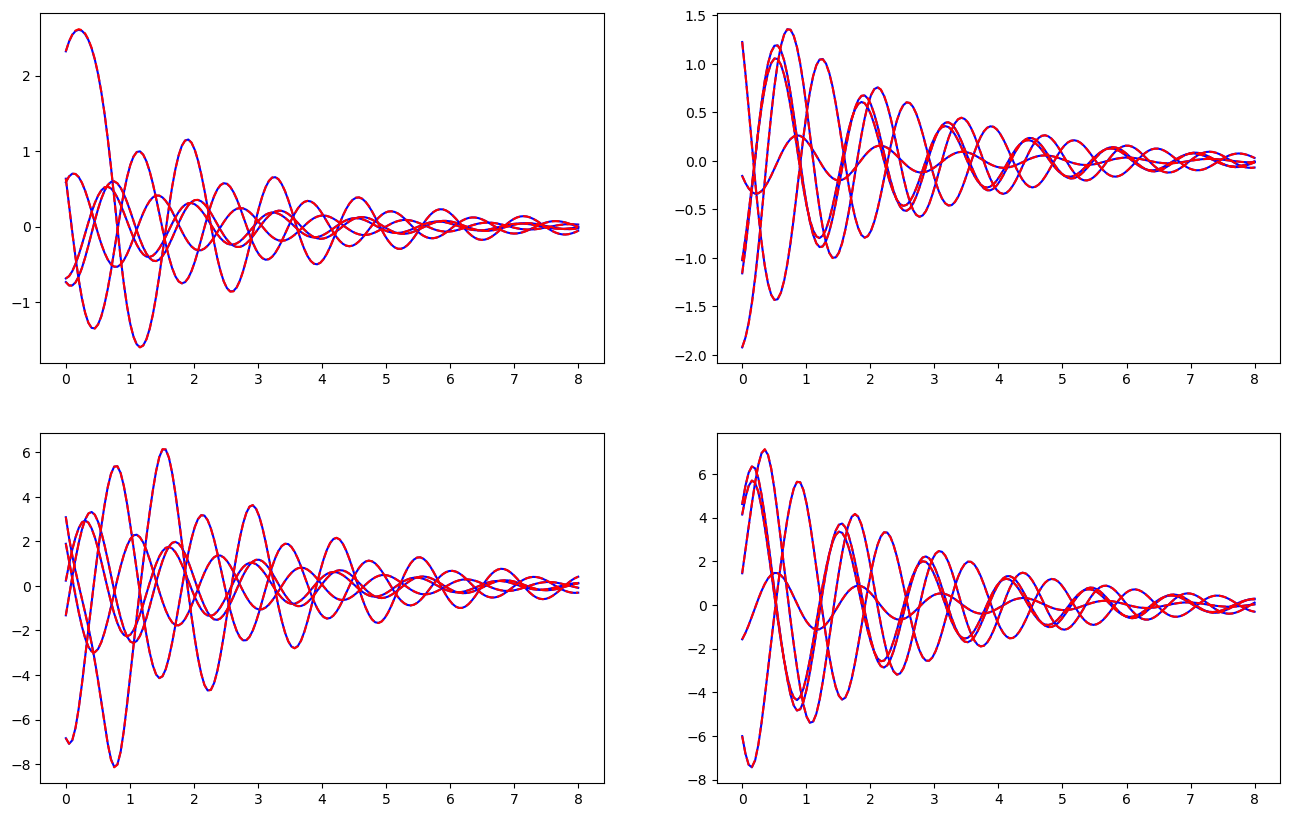

In [16]:
with torch.no_grad():
    predicted_trajectories = model(y_0s, ts).permute(1, 0, 2).cpu().numpy()
    predicted_trajectories_val = model(y_0s_val, ts).permute(1, 0, 2).cpu().numpy()

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
for trajectory in trajectories_list[:5]:
    thetas, omegas = trajectory[:, 0].cpu().tolist(), trajectory[:, 1].tolist()
    axs[0, 0].plot(ts, thetas, 'b')
    axs[1, 0].plot(ts, omegas, 'b')

for predicted_trajectory in predicted_trajectories[:5]: 
    thetas, omegas = predicted_trajectory[:, 0].tolist(), predicted_trajectory[:, 1].tolist()
    axs[0, 0].plot(ts, thetas, 'r--')
    axs[1, 0].plot(ts, omegas, 'r--')

for trajectory in trajectories_list_val:
    thetas, omegas = trajectory[:, 0].cpu().tolist(), trajectory[:, 1].tolist()
    axs[0, 1].plot(ts, thetas, 'b')
    axs[1, 1].plot(ts, omegas, 'b')

for predicted_trajectory in predicted_trajectories_val: 
    thetas, omegas = predicted_trajectory[:, 0].tolist(), predicted_trajectory[:, 1].tolist()
    axs[0, 1].plot(ts, thetas, 'r--')
    axs[1, 1].plot(ts, omegas, 'r--')

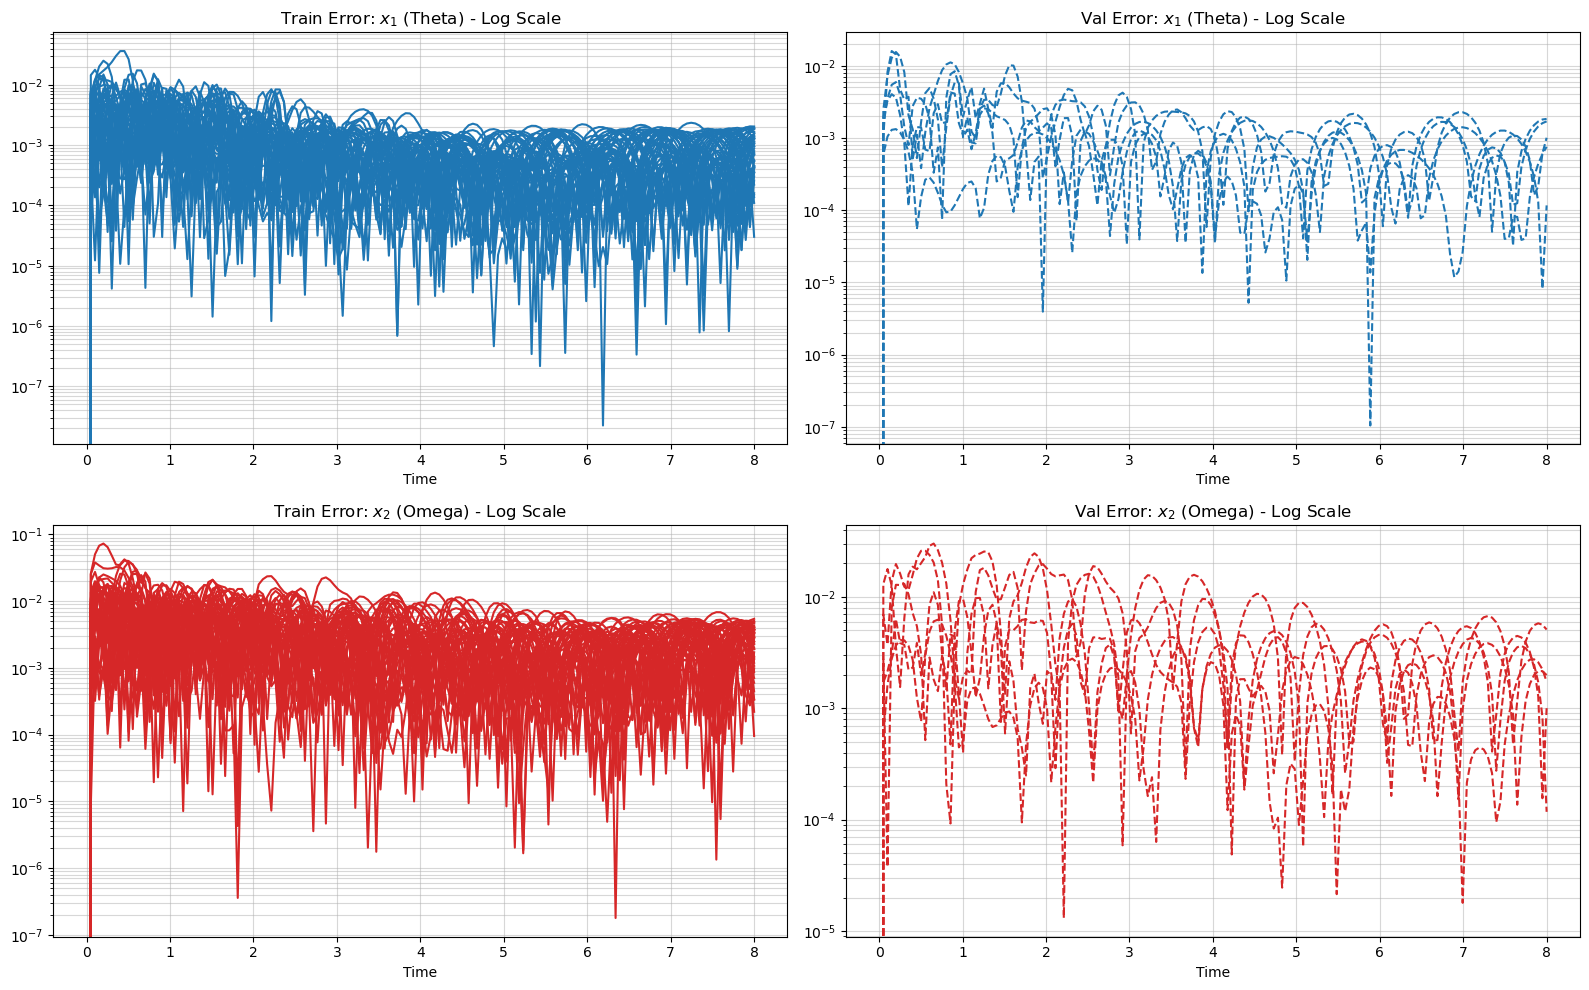

In [17]:
import numpy as np

train_error = np.abs(trajectories.cpu().numpy() - predicted_trajectories)
val_error = np.abs(trajectories_val.cpu().numpy() - predicted_trajectories_val)

ts_np = ts.cpu().numpy()

fig, axs = plt.subplots(2, 2, figsize=(16, 10))

axs[0, 0].plot(ts_np, train_error[:, :, 0].T, color='tab:blue')
axs[0, 0].set_yscale('log')
axs[0, 0].set_title('Train Error: $x_1$ (Theta) - Log Scale')
axs[0, 0].set_xlabel('Time')
axs[0, 0].grid(True, which="both", ls="-", alpha=0.5)

axs[1, 0].plot(ts_np, train_error[:, :, 1].T, color='tab:red')
axs[1, 0].set_yscale('log')
axs[1, 0].set_title('Train Error: $x_2$ (Omega) - Log Scale')
axs[1, 0].set_xlabel('Time')
axs[1, 0].grid(True, which="both", ls="-", alpha=0.5)

axs[0, 1].plot(ts_np, val_error[:, :, 0].T, color='tab:blue', linestyle='--')
axs[0, 1].set_yscale('log')
axs[0, 1].set_title('Val Error: $x_1$ (Theta) - Log Scale')
axs[0, 1].set_xlabel('Time')
axs[0, 1].grid(True, which="both", ls="-", alpha=0.5)

axs[1, 1].plot(ts_np, val_error[:, :, 1].T, color='tab:red', linestyle='--')
axs[1, 1].set_yscale('log')
axs[1, 1].set_title('Val Error: $x_2$ (Omega) - Log Scale')
axs[1, 1].set_xlabel('Time')
axs[1, 1].grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
plt.show()